# 헬스잇(HealthEat) 경구약제 객체검출 — 최종 리포트
> **LHK / Model Architect** · 기획 → 대회(캐글 [AI12]) → 상용화 설계 전체 여정 · 2026-07

**한 줄 요약 — "점수를 올리기 전에, 점수를 믿을 수 있게."**
정직한 평가 체계를 먼저 세우고 한 번에 한 변수씩 검증하며 여러 통념(더 많은 데이터·더 큰 해상도·더 큰 모델이 항상 낫다)을
데이터로 반증했고, **우리 자신의 데이터 누수까지 스스로 잡아냈다.** 그 규율 위에서 **문제의 본질이 '클래스 커버리지'임을 실증**해
56클래스 0.71 → 118클래스 0.99로, 자동 라벨정리·용량·**WBF 앙상블**로 **public 0.9994(best)**에 도달했다. 그리고 상용
검출→검색 아키텍처, 재사용 멀티머신 인프라, Codex 데이터 엔지니어링 3트랙까지 자산화했다.

*(가벼운 표·시각화는 실제 실행 셀, 무거운 학습은 결과·리더보드 점수 인용. 데이터=`reports/data/`, 이미지=`reports/img/`.)*


In [1]:
import json, warnings
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Image, display
warnings.filterwarnings('ignore')
KF = font_manager.FontProperties(fname='/System/Library/Fonts/AppleSDGothicNeo.ttc')
DATA = Path('reports/data'); IMG = Path('reports/img')
pd.set_option('display.max_colwidth', 40)
print('setup OK ·', 'data' if DATA.exists() else 'no-data', '·', 'img' if IMG.exists() else 'no-img')


setup OK · data · img


## 1. 프로젝트 개요 · 접근 철학
| 항목 | 내용 |
| --- | --- |
| 과제 | 경구약제 객체검출 — 이미지당 0~4알, 대회기본 56클래스(Test 40) → 새 대회 확장 |
| 지표 | 초기 `mAP@[0.75:0.95]`(고-IoU 정밀도) · 새 대회 public mAP |
| LHK 역할 | 모델 설계·평가 하니스·증강/데이터 전략·라벨정리·앙상블·상용 아키텍처·멀티머신 인프라 |

**접근 철학:** ① **정직한 평가 우선**(조합단위 GroupKFold·누수통제) · ② **한 번에 한 변수**(단일변수 애블레이션) ·
③ **메커니즘 > 반복지시**(평가 하니스·자동 라벨감사·git-버스로 재현성을 코드로 강제) · ④ 작고 되돌릴 수 있는 실험.


## 2. 기획 · 설계 (스펙 우선)
코드 이전에 **설계 문서 체계**를 먼저 세웠다(pilldet-mono/docs 00~09). 모델 출력이 실제 약 정보·서비스로 이어지는 전 경로를 설계.

| 문서 | 내용 |
| --- | --- |
| 00 계획 · 01 SRS · 02 PRD | 요구사항·제품 정의(검출→약정보 카드→서비스) |
| 03 실행전략 · 04 **ERD/SSOT** | `category_id ↔ dl_idx ↔ 약정보` 매핑 체인, `drug_master` ETL |
| 05 서빙·배포 | T1(Gradio) / T2(FastAPI+Vercel+Supabase) 토폴로지·API 명세·지연예산 |
| 06 UX·데모 · 07 데이터소스 · 08 오토라벨 | 화면·디스클레이머 / AI Hub 도입 기준 / 세미 오토라벨(크로스워크) |

> **핵심 SSOT:** `class_map.json`(model_index↔category_id) + `drug_master`(category_id↔약정보). 학습·추론·제출·서비스가 모두 이 둘을 참조 → ID 버그의 진원지를 단일화.


## 3. EDA · 데이터 프로파일
- **대회 기본 데이터**: real **232장**(114~232조합)·763 알약 인스턴스·**56 distinct 클래스**(Test 40). `category_id = int(dl_idx)`(결정적 매핑).
- **도메인 특성**: 블루그레이 배경·고IoU 정밀도 요구·저데이터·소수클래스 불균형.
- **평가 설계**: 조합 단위 **GroupKFold(seed=42)** — 같은 조합이 train/val 동시 등장 금지(누수 방지).
- **GT 품질 감사**: 합성 배경 제작 중 '알약 없는 영역'에 실알약 혼입 발견 → 검출기+육안 교차검증으로 **미annotation 13건 확정**(232장 중 13). 무라벨 실알약=FP 처리로 **val 약 0.004 과소평가** → 대회원본 무수정 + 로컬 corrected(8건) 별도운용.


## 4. 베이스라인 — 다중 모델 공정 비교
무지성 모델 선택을 지양하고 **동일 fold·동일 하니스**로 후보를 비교했다(초기 단일폴드 스냅샷).


In [2]:
base = pd.DataFrame([
  ['MPS(로컬)','YOLO11n',0.686,'최소 파라미터로 최고, turnkey'],
  ['MPS','RetinaNet',0.58,'소데이터 수렴 열세'],
  ['MPS','YOLO26n',0.48,''],
  ['MPS','FCOS',0.19,''],
  ['CUDA(Colab)','RT-DETR-l',0.737,'트랜스포머-DETR, 전체 1위'],
  ['CUDA','FasterRCNN',0.655,'MPS 0.0=발산 진단→warmup 복구'],
], columns=['트랙','모델','mAP(fold0)','메모'])
base


,트랙,모델,mAP(fold0),메모
0,MPS(로컬),YOLO11n,0.686,"최소 파라미터로 최고, turnkey"
1,MPS,RetinaNet,0.580,소데이터 수렴 열세
2,MPS,YOLO26n,0.480,
3,MPS,FCOS,0.190,
4,CUDA(Colab),RT-DETR-l,0.737,"트랜스포머-DETR, 전체 1위"
5,CUDA,FasterRCNN,0.655,MPS 0.0=발산 진단→warmup 복구


> **시행착오:** FasterRCNN이 MPS에서 mAP 0.0 → '버그가 아니라 학습 발산'으로 진단(검출수 0 근거), warmup·lr 조정으로 0.655 복구. — 숫자를 의심해 원인을 규명한 첫 사례.


## 5. 증강 — 합성의 도약, 그러나 '물량'은 플래토
AI Hub 단일 알약을 도메인(블루그레이)에 맞춰 조합 합성(SAM2 알파 매트 → 구조적 Copy-Paste). **합성 696장이 큰 도약**(클래스 커버리지). 그러나 그 이상 물량·분포는 오르지 않음(3폴드 평균, 누수無).


In [3]:
aug = pd.DataFrame([
  ['real만',0.726,''],
  ['+ 합성696',0.905,'합성의 도약 (+0.18)'],
  ['+ 합성696+1500(자연분포)',0.896,'플래토'],
  ['+ 합성696+2500(균형분포)',0.909,'플래토(균형강제도 개선 아님)'],
], columns=['데이터','mAP(3폴드평균)','메모'])
aug


,데이터,mAP(3폴드평균),메모
0,real만,0.726,
1,+ 합성696,0.905,합성의 도약 (+0.18)
2,+ 합성696+1500(자연분포),0.896,플래토
3,+ 합성696+2500(균형분포),0.909,플래토(균형강제도 개선 아님)


## 6. 평가 신뢰도 — 3대 함정 (이 프로젝트의 핵심 스토리)
**함정 ① 단일폴드는 순위를 못 가린다(노이즈).** fold0 하나에선 `696=0.933 → +2500=0.917 → +1500=0.871`처럼 '데이터 늘렸는데 하락'. 부트스트랩 **95% CI 전부 겹침**(val 51장). → **3폴드 GroupKFold** 폴드평균으로 판정(§5 표), 하락은 노이즈로 확정.

**함정 ② 대회 GT가 실알약 일부 누락.** 13건 확정, val 약 0.004 과소평가(§3).

**함정 ③ '0.960 vs 0.933' 채점 불일치 → 지표 범위 차이.** 하나는 mAP@[0.50:0.95](표준 COCO), 하나는 mAP@[0.75:0.95](대회). 버그 아님. → 지표 라벨 항상 명시, 대회 정답=0.75:0.95로 통일.

> **교훈:** 세 함정 모두 '그럴듯한 숫자'를 의심해 파고든 결과. **평가를 믿을 수 있게 만든 뒤에야** 이후 모든 실험이 의미를 가졌다.


## 7. 용량 · 해상도 · real-copy 누수 (자기검증)
데이터축이 막히자 다른 축을 검증(전부 누수無·대회지표).


In [4]:
cap = pd.DataFrame([
  ['YOLO11n','2.6M',0.905,''],
  ['YOLO11s','9.4M',0.930,'스윗스팟 (+0.025)'],
  ['YOLO11m','20M',0.907,'base 877장 데이터기아→과적합'],
], columns=['모델','파라미터','mAP(3폴드)','메모'])
cap


,모델,파라미터,mAP(3폴드),메모
0,YOLO11n,2.6M,0.905,
1,YOLO11s,9.4M,0.930,스윗스팟 (+0.025)
2,YOLO11m,20M,0.907,base 877장 데이터기아→과적합


- **용량은 비단조** — 11s가 스윗스팟. 11m은 base에선 데이터기아(에폭 100으로도 회복 안 됨) → '더 큰 모델엔 더 많은 데이터' 실증(11m 진짜 판정은 데이터 확장 후로 보류).
- **해상도 폐기** — 학습·추론 960은 11n·11s 양쪽에서 640보다 하락.
- **real-copy 누수 자기검증** — real 알약 재조합 증강이 처음 최고(0.945)로 보였으나, `source_file`을 폴드에 매핑하니 소스=fold0-train 181장 → **fold1·2 val 알약이 train에 재등장=누수 확정**. 누수 없는 fold0에선 오히려 하락 → '+0.015'는 누수 산물, **무효화**. (남이 아니라 우리 결과를 스스로 의심해 잡아낸 사례.)


## 8. AI Hub 조합 데이터 = 진짜 레버 ('0.93 천장' 정정)
'0.93이 천장'이라 본 것은 **좁은 실험 슬라이스만 판 오판**이었다. 리더보드 현실은 0.98~0.99. 미시도 핵심 레버는 **AI Hub 금지-아닌 조합 real 데이터**.
- **누수 검증 통과**: aihub 조합 ∩ 대회232 = 0, ∩ fold0-val = 0, 이미지완전일치 = 0 → real-copy와 정반대(같은 클래스·다른 조합·다른 사진 = 진짜 새 real).
- fold0 **+0.021 clean** · 스케일: POC 2,099장 → **FULL 7,836장/54클래스**. 인페인트 마스킹(하드 사각형→cv2.inpaint seamless)으로 아티팩트 제거.
- **리더보드 궤적**: 0.958 → 0.972 → **0.985**. 로컬 fold0 0.983 ≈ 리더보드 0.985 → **캘리브레이션 정렬 증명**(로컬 판정 신뢰).

> 강한 aug(0.841)·오버샘플(0.906)·회전은 전부 fold0 하락 = 진짜 안 통함. 부족했던 건 '진짜 real'이었음이 확정.


## 9. 대회 교체 [AI12] — 커버리지 대전환 (56 → 118) ★
새 리더보드([AI12])는 **같은 test842 이미지 + 확장된 GT(클래스 71~79)**로 채점. 56만 잡는 모델은 급락(0.71~0.74), 전 클래스 학습팀은 0.95+. **병목은 정확도가 아니라 커버리지**였다.
- AI Hub 조합 라벨엔 **116 클래스 이미 존재**(우리가 62개를 인페인트로 지워온 것) → 안 지우고 **전량 추출 10,489장** → real56 ∪ aihub116 = **118클래스**(인페인트 불필요, 오히려 단순).


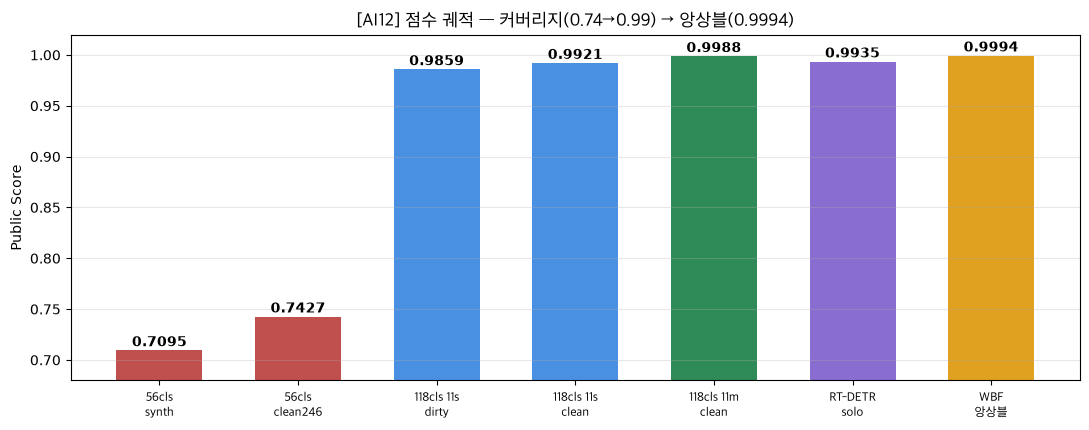

In [5]:
labels = ['56cls\nsynth','56cls\nclean246','118cls 11s\ndirty','118cls 11s\nclean','118cls 11m\nclean','RT-DETR\nsolo','WBF\n앙상블']
scores = [0.7095, 0.7427, 0.9859, 0.9921, 0.9988, 0.9935, 0.9994]
cols = ['#c0504d','#c0504d','#4a90e2','#4a90e2','#2e8b57','#8a6dd0','#e0a020']
fig, ax = plt.subplots(figsize=(11,4.4))
b = ax.bar(range(len(scores)), scores, color=cols, width=0.62)
for r,s in zip(b,scores): ax.text(r.get_x()+r.get_width()/2, s+0.004, f'{s:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0.68,1.02); ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontproperties=KF, fontsize=9)
ax.set_ylabel('Public Score'); ax.set_title('[AI12] 점수 궤적 — 커버리지(0.74→0.99) → 앙상블(0.9994)', fontproperties=KF, fontsize=13)
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()


In [6]:
def summ(fn, label):
    p = DATA/fn
    if not p.exists(): return {'제출본':label,'상태':'(경로참조)'}
    df = pd.read_csv(p); n=df.image_id.nunique()
    return {'제출본':label,'rows':len(df),'이미지':n,'검출클래스':df.category_id.nunique(),'박스/img':round(len(df)/n,1)}
pd.DataFrame([summ('submission_yolo11m_full232_synth696_aihubfull_cover118_clean.csv','11m clean (0.9988)'),
              summ('submission_wbf_11m_rtdetr_skip03.csv','WBF 앙상블 (0.9994)')])


,제출본,rows,이미지,검출클래스,박스/img
0,11m clean (0.9988),3238,842,76,3.8
1,WBF 앙상블 (0.9994),3289,842,81,3.9


## 10. 자동 라벨정리 — 2트랙 감사
AI Hub 소스 라벨 자체가 dirty(비박스 오배치·라벨누락). 사람이 수천 장을 볼 수 없어 **모델 불일치 + 기하 휴리스틱 2트랙**으로 의심 라벨을 자동 랭킹(사람은 상위만 수분 검수). cover116에서 **485건(4.5%) 검출**, 전량제거 fold0 +0.0027(라벨누락까지 제거가 박스오류만 제거보다 나음), 캐글 clean>dirty +0.0062.


In [7]:
s = pd.read_csv(DATA/'cover116_suspects.csv')
FM = [('missing_gt','라벨누락'),('no_pred_match','위치오류'),('class_mismatch','클래스오류'),('loose_bbox','박스느슨'),('out_of_bounds','경계이탈'),('size_outlier','크기이상'),('extreme_aspect','비율이상')]
print(f'총 의심: {len(s)}장 / 10,721 (4.5%) · aihub {int((s.source=="aihub").sum())} · real {int((s.source=="real").sum())}')
pd.Series({kor:int(s.flag_types.str.contains(k).sum()) for k,kor in FM}).sort_values(ascending=False).to_frame('이미지수(중복가능)')


총 의심: 485장 / 10,721 (4.5%) · aihub 479 · real 6


,이미지수(중복가능)
라벨누락,391
클래스오류,138
위치오류,130
박스느슨,80
경계이탈,58
크기이상,34
비율이상,26


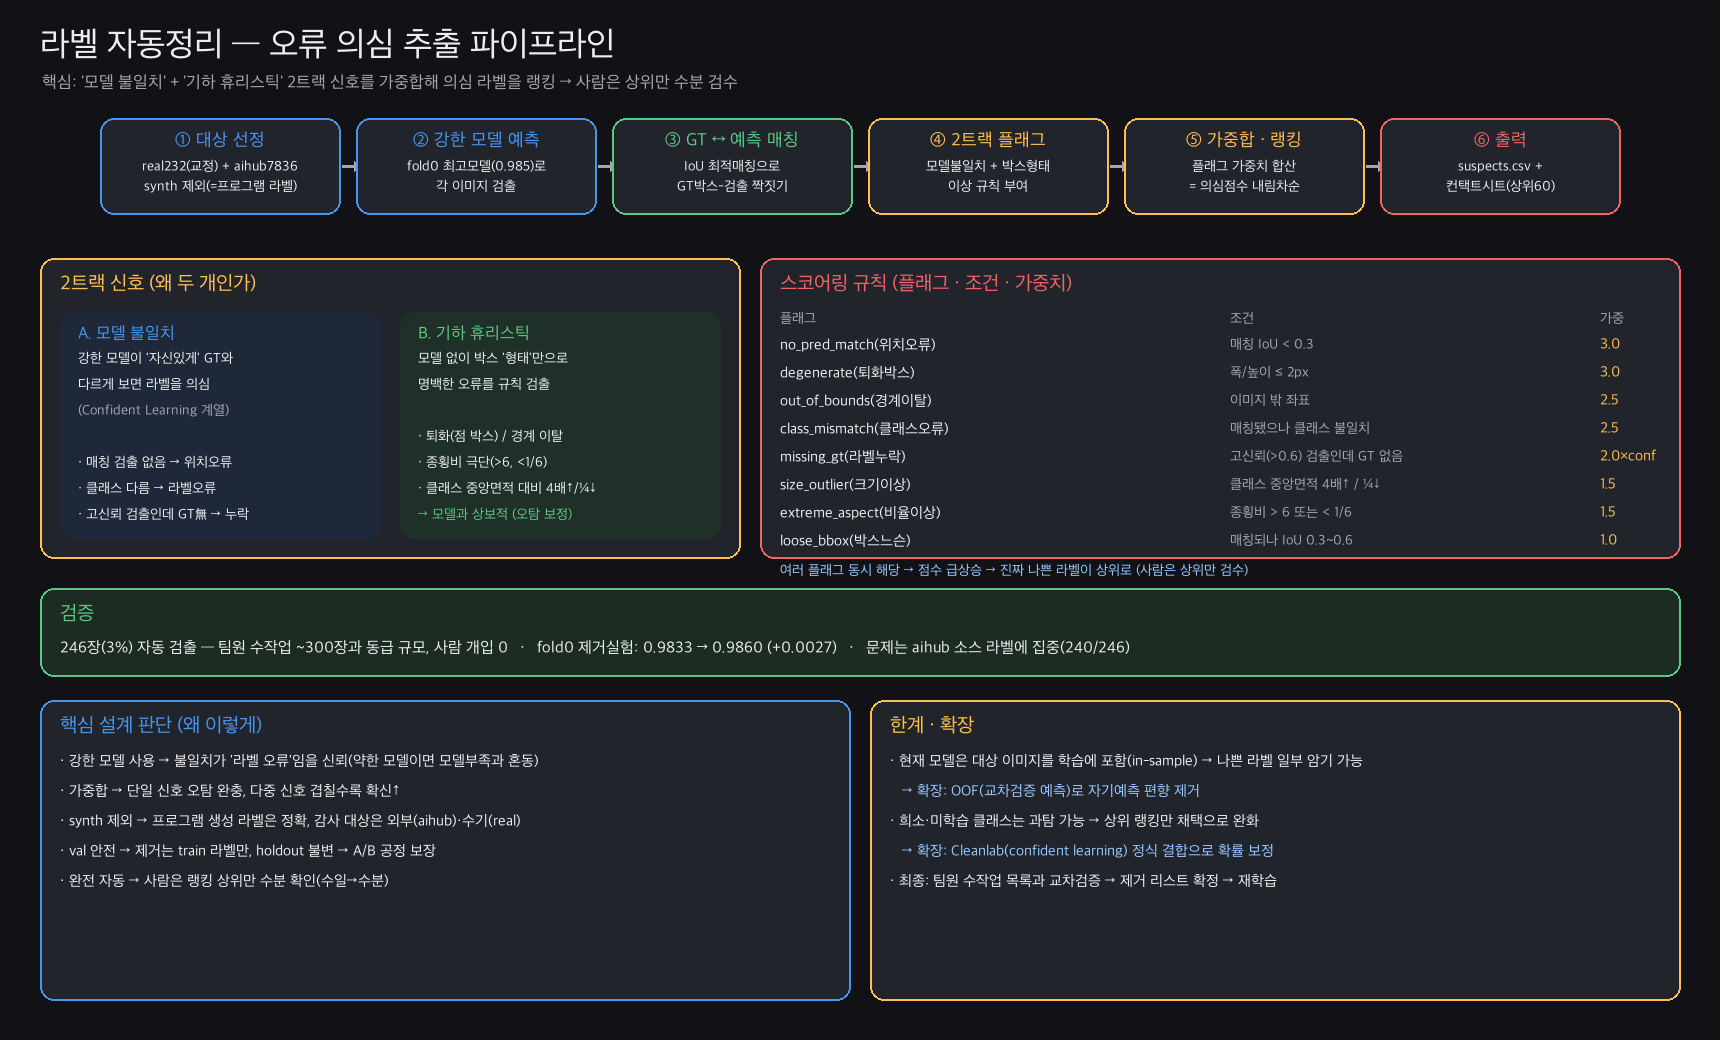

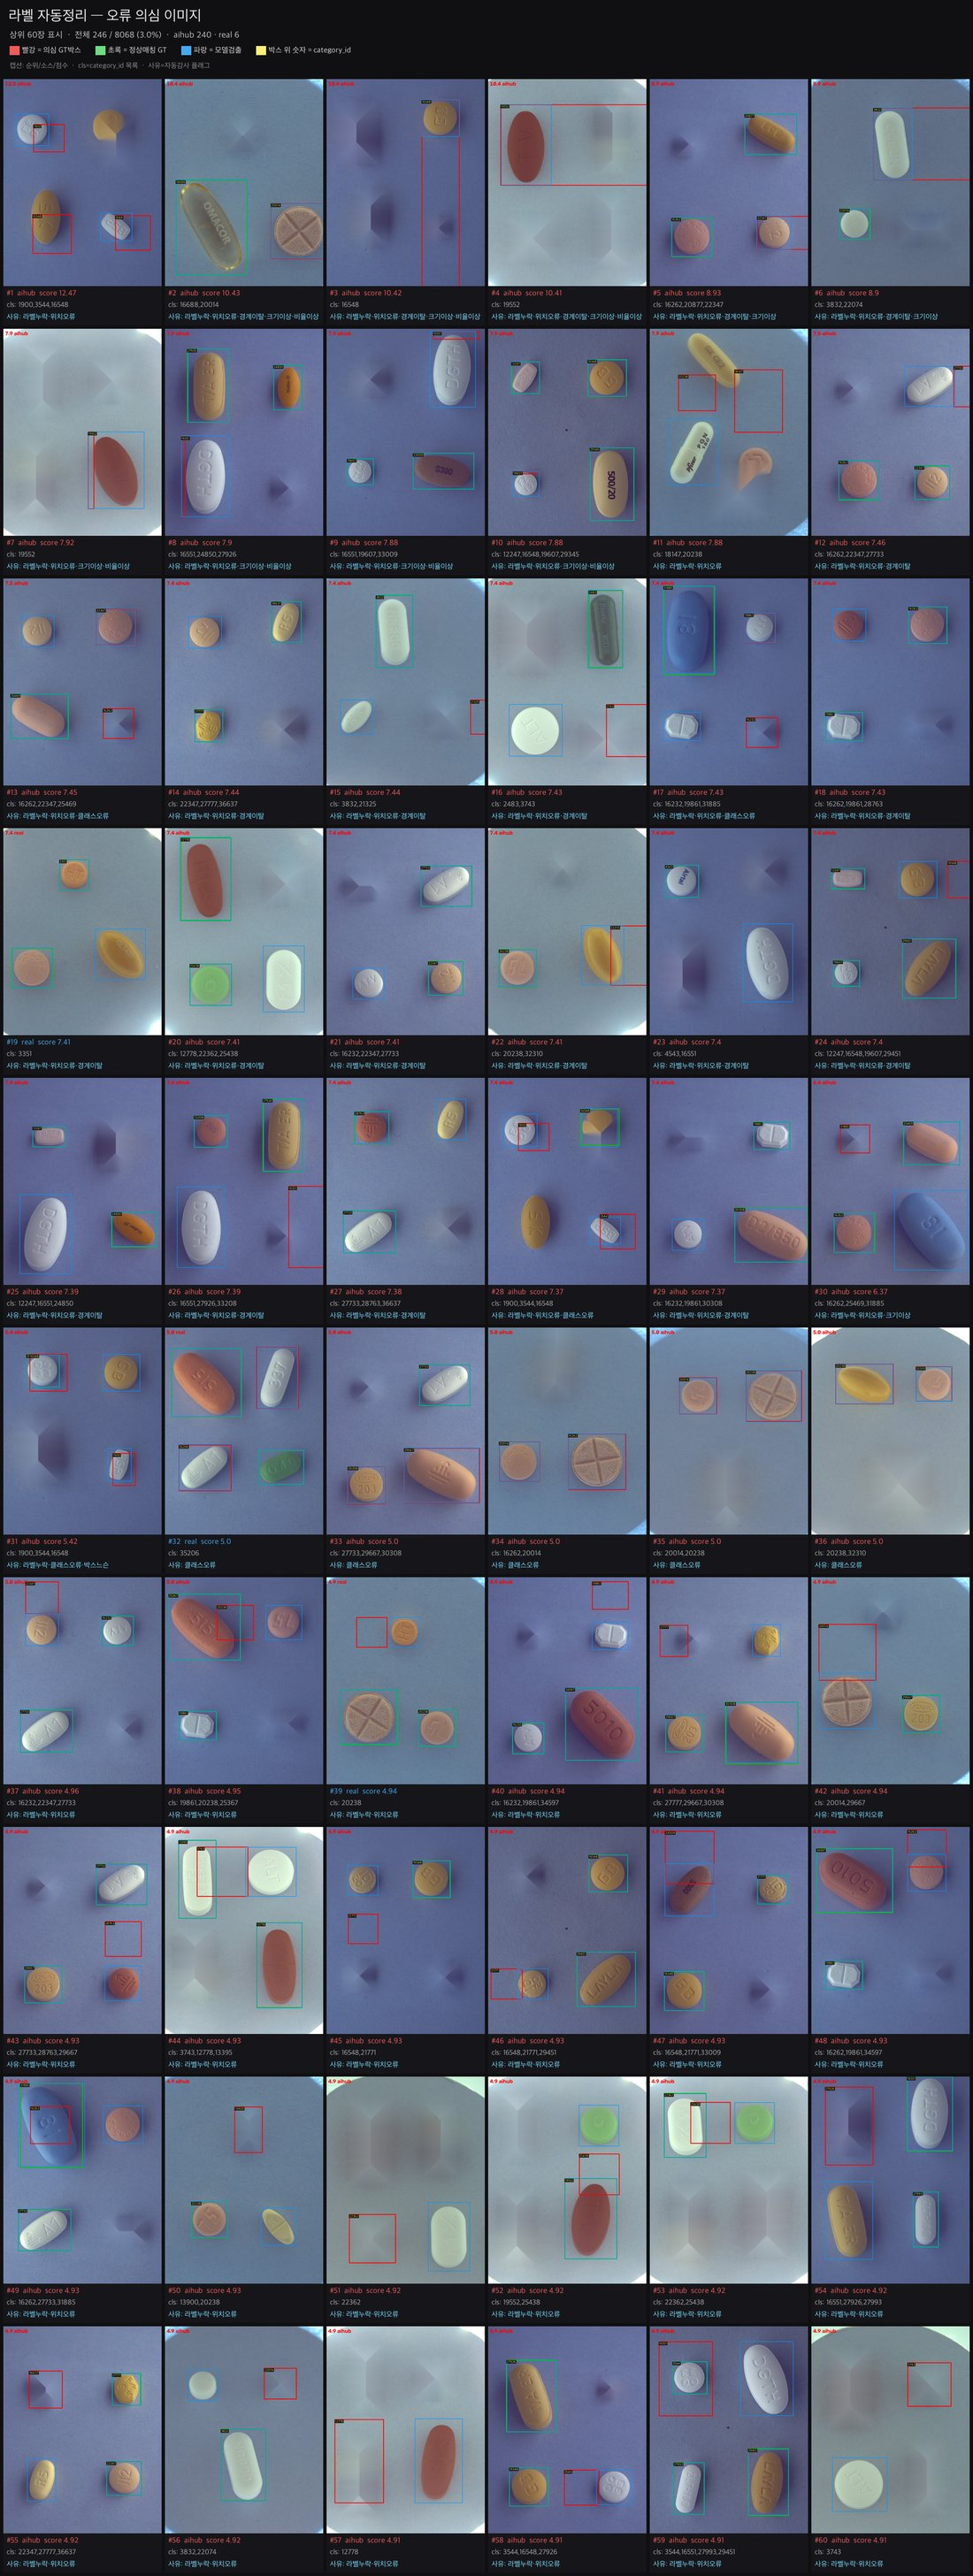

In [8]:
display(Image(str(IMG/'report_03_label_audit_pipeline.png')))
display(Image(str(IMG/'report_01_label_audit_suspects_grid.jpg')))


## 11. 용량 · 앙상블 — 마지막 한 방울
- **11m(용량↑·보수적) > 11s** (0.9988 vs 0.9921) — 이 지표는 정밀도(오탐억제)를 보상 → 클래스를 더 잡은 11s가 오히려 손해.
- **RT-DETR**(트랜스포머·NMS-free) 다양성 + **WBF 앙상블**. 30박스/img를 그대로 섞으면 폭증본이 되어 하락 위험 → **보수적 융합**(skip_box_thr 0.2~0.3, ~4/img)으로 합의 박스만 정밀화 → **0.9994(+0.0006)**.
- 예측버그(MPS INT_MAX·CUDA OOM)는 **per-image 예측**으로 회피.


## 12. 데이터 엔지니어링 3트랙 (Codex)
상용 커버리지(~25,000 클래스)를 위해 Codex가 **수집 → 경량화 → 오토라벨 V2**를 구축(우리 모델링과 나란히).


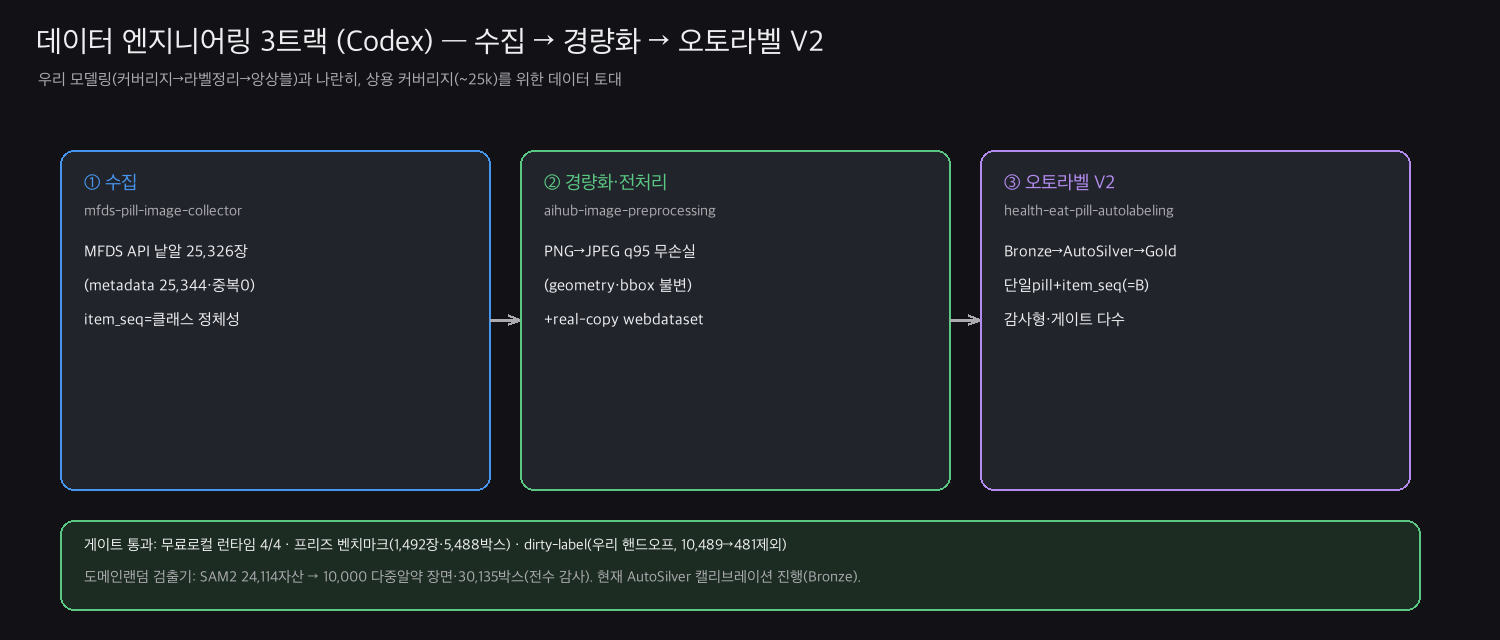

In [9]:
display(Image(str(IMG/'report_07_data_engineering_3tracks.png')))


- **① 수집** `mfds-pill-image-collector`: MFDS API 낱알 **25,326장**(metadata 25,344·중복0). `item_seq`=클래스 정체성.
- **② 경량화·전처리** `aihub-image-preprocessing`: PNG→**JPEG q95 무손실**(geometry·bbox 불변) + real-copy webdataset 핸드오프.
- **③ 오토라벨 V2** `health-eat-pill-autolabeling`: **Bronze→AutoSilver→Gold** 감사형, **단일 pill 검출 + item_seq 식별**(=상용 B). 게이트: 런타임4/4·프리즈벤치마크(1,492장·5,488박스)·dirty-label(**우리 핸드오프 10,489→481제외**)·도메인랜덤(10,000장·30,135박스).

**118 클래스 카탈로그**(우리 커버리지 학습 클래스, id·K-code·제품명):


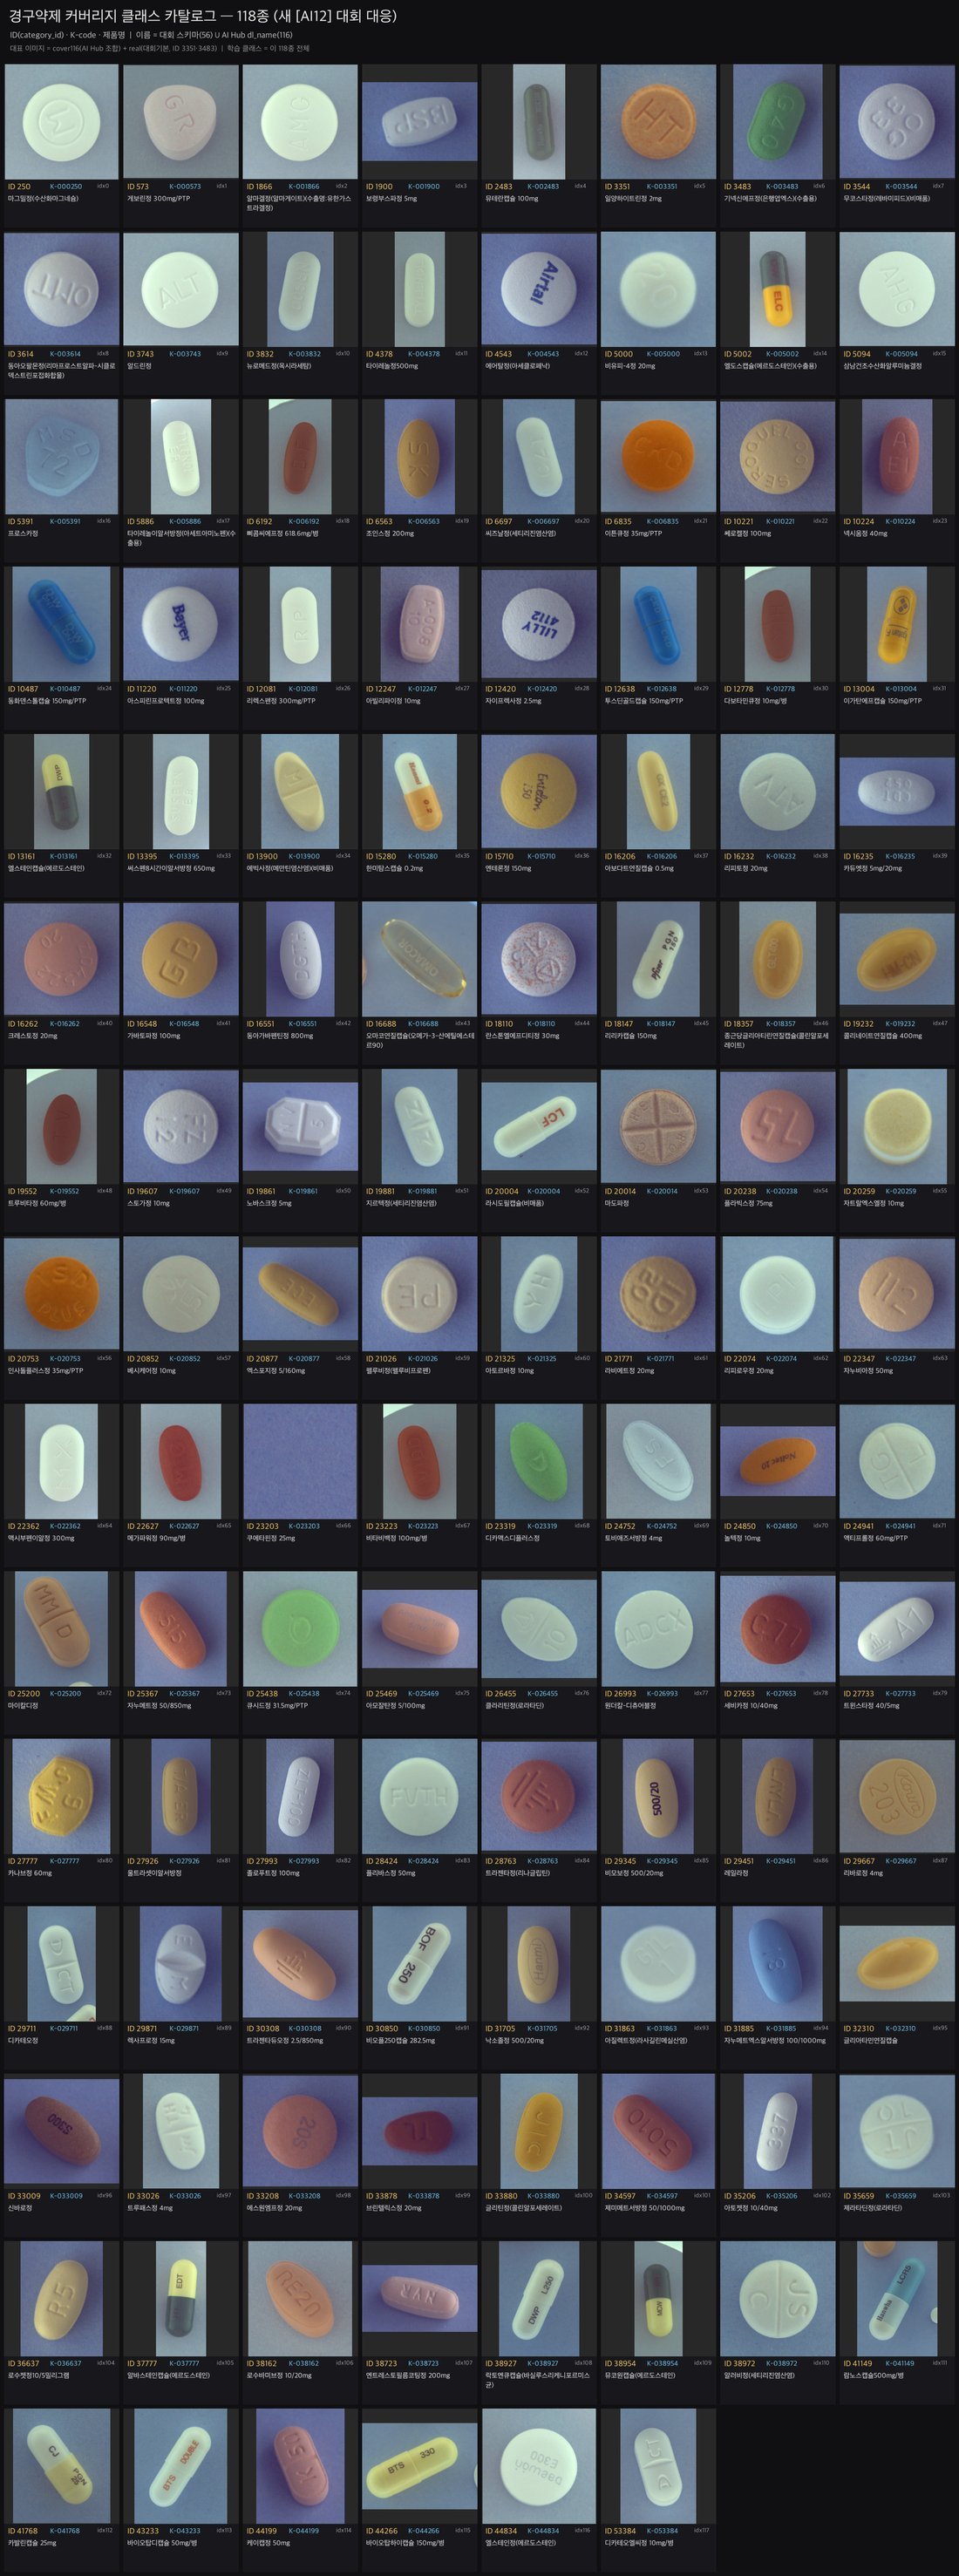

In [10]:
display(Image(str(IMG/'report_02_class_catalog_118.jpg')))


## 13. 상용 서비스 설계 — 검출 → 검색 (A→B)
소프트맥스 검출헤드는 25k 미세식별에 무리 + **파레토**(제품 외형 80%커버≈1~3천).
- **1차 A(단일 검출기, 큐레이션 1~3천)** — 캐글 승자 파이프라인 계승, 빠른 출시.
- **확장 B(검출+임베딩 검색, 전체 25k+)** — 신약=재학습 아닌 **등록(enroll)**, top-k, '미상=확인필요'(의료안전). Codex가 이미 B의 검출 토대 구축.
- 서빙: FastAPI+Vercel+Supabase+e약은요(임상정보), 문서 05·04 계승.


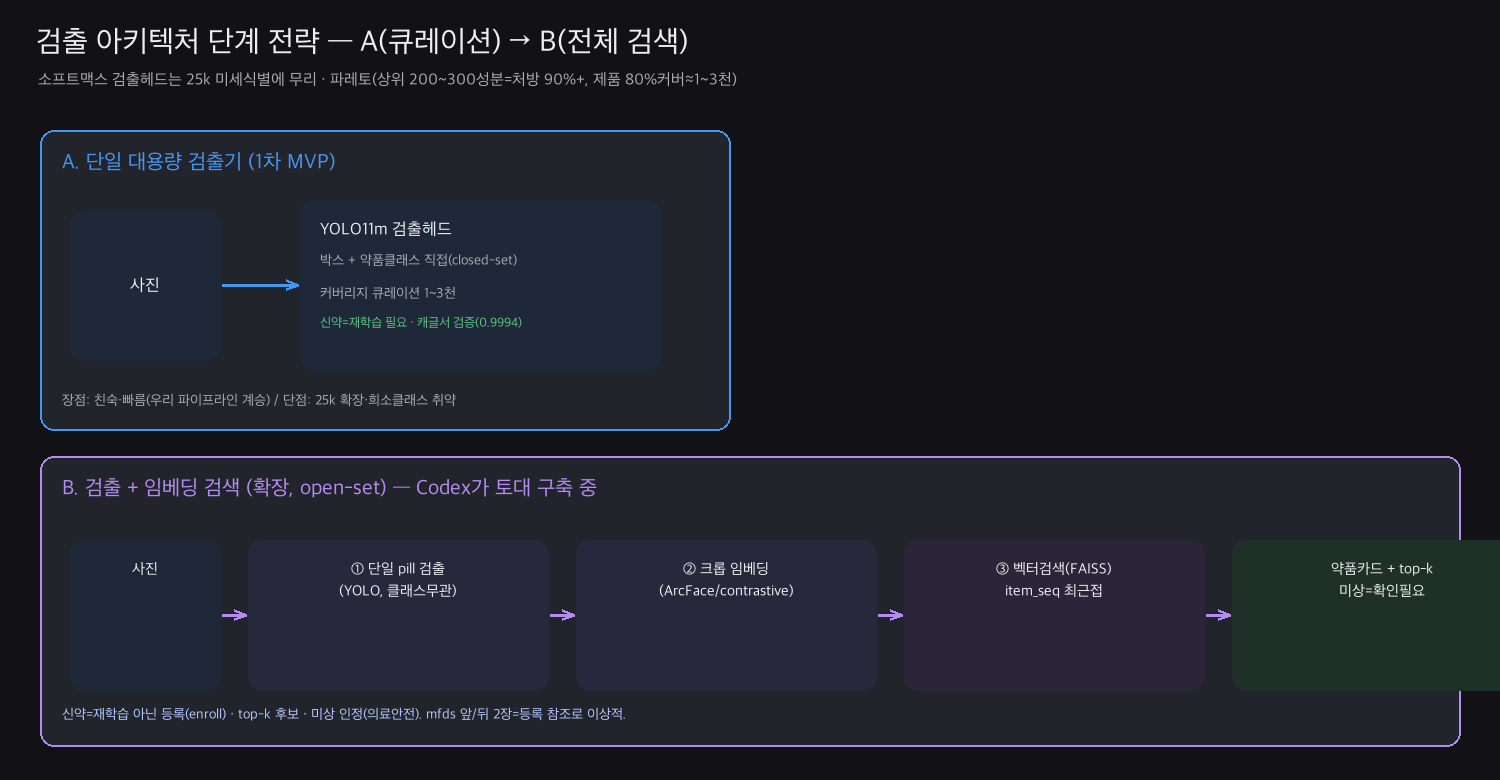

In [11]:
display(Image(str(IMG/'report_05_architecture_A_to_B_detect_retrieve.png')))


## 14. 멀티머신 인프라 (재사용 자산)
3머신(MacBook·Mac Studio·Colab) 병렬, **git=버스**(코드·소결과) + 대회 후 **썬더볼트+SMB**(GB/s·상호 로컬급) + **Tailscale**(고정주소·원격)로 수동복사 제거.


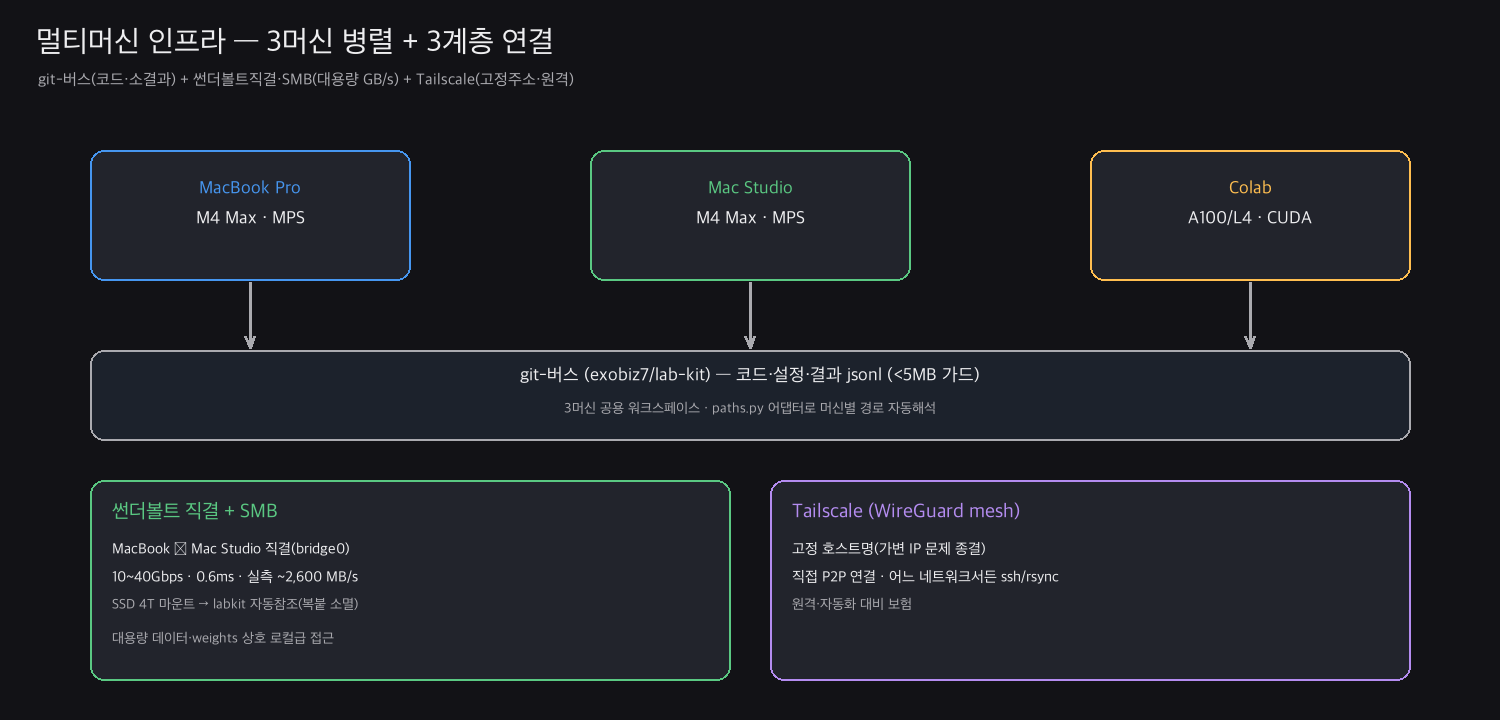

In [12]:
display(Image(str(IMG/'report_06_multimachine_infra.png')))


## 15. 발견 · 통찰 · 교훈
1. **평가부터 믿을 수 있게** — 3대 함정(단일폴드 노이즈·GT누락·지표범위)을 걸러낸 뒤에야 실험이 의미.
2. **더 많은/큰 것이 항상 낫지 않다** — 합성 물량·해상도·모델체급 모두 반례.
3. **출처(source)를 끝까지 추적** — GT누락·real-copy 누수 모두 '어디서 왔나'로 발견(자기검증).
4. **커버리지가 최대 레버** — 56→118(0.74→0.99). 정밀도 지표라 보수적 모델이 유리.
5. **합성 > 물량복제**, **현실적 증강만** 통함(강aug 도메인붕괴).
6. **자동 라벨정리 유효**(2트랙, +0.006), **앙상블은 '어떻게'**(폭증 폐기·보수적 융합).
7. **검출헤드 한계 + 파레토 → A→B 단계전략**. AI Hub 소스 라벨 dirty(우리·Codex 양측 실증).


## 16. 자산 · 재현 · 맺음
- **코드/실험**(git-버스 `exobiz7/lab-kit`): `label_audit.py`·`wbf_ensemble.py`·`aihub_extract_cover.py`·`final_submission.py`·`kfold_exp.py`·`make_*` 시각화·RT-DETR resumable 노트북.
- **설계문서**: `pilldet-mono/docs/00~09`(09=상용 로드맵), LHK `중간리포트_ModelArchitect.md`·`augmentation_design.md`·`02~04` 노트북.
- **Codex 레포**: `github.com/exobiz7/{health-eat-pill-autolabeling, mfds-pill-image-collector}` + `aihub-image-preprocessing`(로컬).
- **무거운 자산(→ 팀 구글드라이브)**: `reports/TEAM_DRIVE_ASSETS.md` 참조(weights·cover116·번들·제출CSV·풀해상도 시각자산).

### 맺음
이 프로젝트의 성과는 특정 점수가 아니라 **믿을 수 있는 결론을 내는 과정**이다. 통념을 데이터로 검증하고 노이즈·누락·누수를 걸러냈으며,
문제의 본질(커버리지)을 실증해 0.9994에 이르렀다. 커버리지·라벨정리·앙상블·검출→검색 설계는 그대로 상용(Phase 3~4)으로 이어진다.
